<a href="https://colab.research.google.com/github/mwetmore05/A03-knn/blob/main/notebook_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Maggie Wetmore

**Date:** 09/30/26

#1

1-1. Regression predicts a numeric outcome. Versus classification predicts a category.

1-2. A confusion table counts predictions by actual class and predicted class. It helps us understaand misclassifications/miscalculations of a model to understand its performance. It shows the accuracy.

1-3. SSE quanitifys the residuals which is the  size of prediction error. Lower validation SSE means smaller errors on the validation set.

1-4. Overfitting is when the model has a very small k can overfit the noise in the training data. Underfitting is when the model has a very large k and can underfit by giving nearly the same prediction for every observation.

1-5. We split the data see how well the model predicts new observations. The model is fit using training set, and then different values of k are compared using accuracy or SSE on a separate validation set. This helps us choose k that works better on new data instead of only fitting the training data. Results can also depend on how the data is split.

1-6. Class label gives a simple prediction and is easy to understand but does not show how uncertain the model is. probability distribution gives the proportion for each possible classgiving more info about how confident the prediction is but it is more complicated to interpret than just giving one class label.

#2

##2-1

In [ ]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd #importing packages!
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive') #allowing google drive
data = pd.read_csv('/content/land_mines.csv') #downloading the data
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [ ]:
data.info() #performing eda absed on fucntions we used last section, to observe data
data.describe()
data.isna().sum()
data["mine_type"].value_counts().sort_index()
data.groupby("mine_type")[["voltage", "height", "soil"]].mean()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB


,voltage,height,soil
mine_type,,,
1,0.296463,0.495519,0.492958
2,0.721123,0.487013,0.508571
3,0.402408,0.527548,0.496970
4,0.345365,0.506887,0.503030
5,0.379598,0.530070,0.516923


<Axes: >

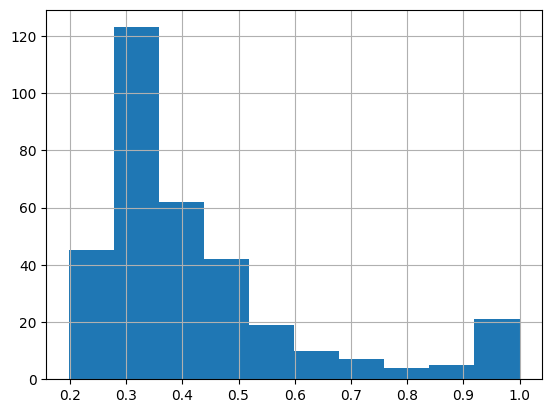

In [ ]:
data["voltage"].hist() #looking at varible dist.

<Axes: >

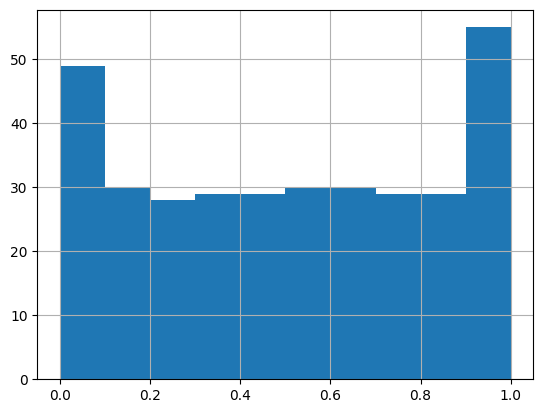

In [ ]:
data["height"].hist() #looking at varible dist.

<Axes: >

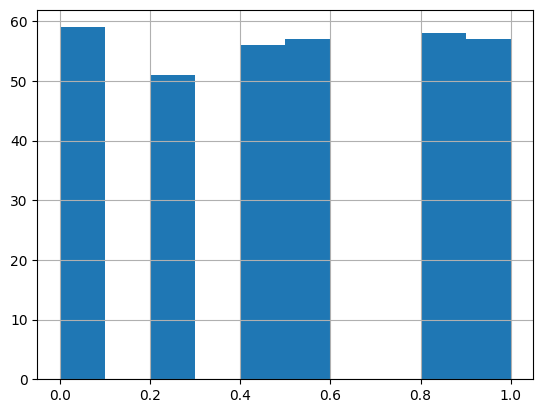

In [ ]:
data["soil"].hist() #looking at varible dist.

The dataset for land mines has 338 observations and 0 missing values. The target varibale is mien type and contains 5 classes that are relatively evenly distributed. The features are voltage, neigh, and soil. I examined the summary statistics and distributions of the 3 features, voltage is concentrated aorund lower values mostly, and height and soils are more spread out.

##2-2

In [ ]:
from sklearn.model_selection import train_test_split
# imported function used to split data found in slides, then selected target feature, then variable...
X_raw = data[["voltage", "height", "soil"]]
y = data["mine_type"]

(X_train_raw,X_test_raw, y_train, y_test,) = train_test_split(X_raw,y,test_size=0.50,random_state=65)
#putting 50% data in test set and making split reproducible
from sklearn.preprocessing import MinMaxScaler #import feature scaling method

scaler = MinMaxScaler() #create the scaler

X_train = scaler.fit_transform(X_train_raw) #train and test like the slides
X_test = scaler.transform(X_test_raw)

##2-3

In [ ]:
from sklearn.neighbors import KNeighborsClassifier #importing

ks = np.arange (1,51)
valid_accuracy = []

for k in ks:
    candidate = KNeighborsClassifier(n_neighbors=int(k)) # like in slides, loops k value and creates the knn model fitted on the training data
    candidate.fit(X_train, y_train)
    test_hat = candidate.predict(X_test) # predic test data
    valid_accuracy.append(
        np.mean(y_test.to_numpy() == test_hat) #calc and store accuray
    )
k_star = int(ks[np.argmax(valid_accuracy)]) #finds k with highest accuracy

k_star # displays the betszs k

2

To select k, i test the k values form 1 to 50 and compared the accuracy of ecah model on the test set, base doff that I sleected the k with the highest test accuracy.

##2-4

In [ ]:
best_model = KNeighborsClassifier(n_neighbors=k_star)   #creates model by use of the best k and fits based on training data..
best_model.fit(X_train, y_train)
test_hat = best_model.predict(X_test)   #like in slides
confusion_table = pd.crosstab( #setting up confusion table
    y_test,
    test_hat,
    rownames=["Actual"],
    colnames=["Predicted"])

confusion_table             #printing confusion table


Predicted,1,2,3,4,5
Actual,,,,,
1,21,1,6,4,2
2,0,33,2,3,0
3,5,5,10,6,4
4,13,5,10,9,1
5,10,1,8,7,3


In [ ]:
accuracy = np.mean(y_test.to_numpy() == test_hat) #testing accurancy
accuracy

np.float64(0.44970414201183434)

Base don the accuracy printed, the model has an accuracy about 45%. It performed best on mine 2 and well on mine 1. It performed worse on mine 3,4,5. The table shows the confusion that may types 4 and 5 were often incorrectly predicting as mine type 1 or 3.

##2-5

BAsed on the mdoel and acccuracy of a lot of correct prediciton but also incorrect predictions, I would not rely on the model alone to identify mine types correctly because it is only right less than half of the test obs. The model was alot better predicting mine tyoe 1,2 than 4,5. Because missclassifying a mine could have problems and consequences depending on the context. the model could be used as additional information for reserach but I would not rely or recommend anyone relys on the model.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** b1061d9
- **AI tool and model used:**  GPT-5.6 Sol

### *Prompts used

1. Do I NEED to change any definitions to these questions or am i hitting the key points? No speling or anything pure forgeting any extremely improtant information


2-1,2. How can i make this better if I need to or is there any errors to fix?

2-3,4. How can i make this better if I need to or is there any errors to fix/ is it correct?

2-5. Am I drawing all insights for this analysis?


### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1.
No — you are not missing any extremely important concept in any of these.
For the core ideas:
- 1-1: has the essential difference: numeric outcome vs. categorical outcome.
- 1-2: has the essential purpose of a confusion table: compare actual vs. predicted classes and see classification errors/performance.
- 1-3: has the essential meaning of SSE: prediction error, with lower validation SSE being better.
- 1-4: has the essential small-\(k\) overfitting / large-\(k\) underfitting tradeoff.
- 1-5: has the essential reason for train/validation splitting: choose \(k\) based on performance on unseen data rather than training fit.
- 1-6: has the essential distinction: a class label gives one predicted class, while probabilities give information about uncertainty/confidence across classes.
So if you're asking “Am I forgetting a major idea that would cost me points?”: No. These cover the main concepts.

2-1,2.
Yes, but I would keep it very minimal. What you have already looks like a normal, appropriate exploratory section and I would not add a bunch of extra analysis.
The one thing I would add is a check of the target-class distribution because your written paragraph says the 5 mine types are “relatively evenly distributed,” but your code currently doesn’t actually display that.
data["mine_type"].value_counts()


Or, if your class notes use proportions:
data["mine_type"].value_counts(normalize=True)


That directly supports what you wrote about the five classes.
Otherwise, you already have the important pieces:
- data.info() → dimensions, variables, data types, missing values
- data.describe() → summary statistics
- data["mine_type"].value_counts() → I would add this
- groupby("mine_type")[...].mean() → compare predictors across classes
- Histograms → see distributions of voltage, height, and soil
I wouldn't add correlations, boxplots, pairplots, or anything more advanced unless the assignment specifically asks for them. Especially if you're trying to keep this consistent with what was shown in class, your current code is already enough.
One small code-cleanliness point: you're importing matplotlib.pyplot and seaborn, but you don't actually use either one in this section. You do not need to change that, though; it is completely normal to import packages at the beginning because you'll use them later.
So my recommendation: just add data["mine_type"].value_counts() and leave the rest alone.

2-3,4.
Your code is basically correct, but there is one important conceptual issue I would fix if your assignment distinguishes validation from test data.
Right now in 2-2 you create only:
- X_train
- X_test
- y_train
- y_test
Then in 2-3 you try many values of \(k\) and pick the one with the highest accuracy on the test set.
That means you are using the test set to tune \(k\). The cleaner setup is:
training set → fit models
validation set → choose \(k\)
test set → evaluate the final chosen model once
So your biggest issue is not the syntax; it is that your variable is called valid_accuracy, but you are calculating it on X_test and y_test.
If your assignment intentionally wants you to choose \(k\) using this test split
Then your code itself is fine. I would just rename:
valid_accuracy = []


to:
test_accuracy = []


Then change:
valid_accuracy.append(...)


and:
k_star = int(ks[np.argmax(valid_accuracy)])


to use test_accuracy.
Your sentence underneath would then match what you actually did:
To select \(k\), I tested values from 1 to 50 and compared the accuracy of each model on the test set. I selected the \(k\) with the highest test accuracy.

One other thing I would consider
Because this is classification with 5 classes, you can preserve the proportions of mine_type when splitting:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(    X_raw,    y,    test_size=0.50,    random_state=65,    stratify=y)


stratify=y helps make sure each class appears in roughly the same proportion in both sets.
So, in order of importance:
1. Check whether you are supposed to have a separate validation set.
2. If not, rename valid_accuracy to test_accuracy.
3. stratify=y would be a nice improvement, but it is optional.
4. Everything else in your code looks fine.

2-5.
You are hitting the main insight, but I’d add 2 specific things so the analysis feels complete:
- State the actual overall accuracy instead of only saying “less than half.” That makes your conclusion more concrete.
- Mention the class-level performance more clearly: the model performs better on mine types 1 and 2 and worse on 4 and 5, so performance is not consistent across classes.
You already have the key conclusion:
- the model has a meaningful number of incorrect predictions
- you would not rely on it alone
- it could still be useful as supporting information
- misclassification matters depending on the use case
So I would not add a lot more. Just make those two insights explicit.
A slightly stronger version would be:
Based on the model’s overall accuracy, it makes many correct predictions but also a large number of incorrect predictions. Since the model is correct less than half of the time, I would not rely on it alone to identify mine types. The model performs better for mine types 1 and 2 than for mine types 4 and 5, which shows that its performance is not consistent across classes. Because misclassifying a mine could have consequences depending on the context, the model would be more appropriate as additional information for research rather than as the only method used for classification.

That would be complete without overdoing it.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Telling me i do not need ot add anything I am hitting the necesary points|
| 2 -1,2 |  Modify | I will add in data["mine_type"].value_counts() but I will not remove the import of seaborn / matlibplot because I like it there and it does not need to be removed |
|2-3,4| Accept| This will enhance my code and seems to be osmehting good based on the slideshow. The stratify keeps the different minetype classes in similar proportions in training and stest sets, making it more balanced and representation. Changed the variable name so it is more descriptive|
|2-5|Accept|I was definitely missing some insights drawn from this analysis and it was good to here chat so now I further understand KNN|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

#1

1-1. Regression predicts a numeric outcome. Versus classification predicts a category.

1-2. A confusion table counts predictions by actual class and predicted class. It helps us understaand misclassifications/miscalculations of a model to understand its performance. It shows the accuracy.

1-3. SSE quanitifys the residuals which is the size of prediction error. Lower validation SSE means smaller errors on the validation set.

1-4. Overfitting is when the model has a very small k can overfit the noise in the training data. Underfitting is when the model has a very large k and can underfit by giving nearly the same prediction for every observation.

1-5. We split the data see how well the model predicts new observations. The model is fit using training set, and then different values of k are compared using accuracy or SSE on a separate validation set. This helps us choose k that works better on new data instead of only fitting the training data. Results can also depend on how the data is split.

1-6. Class label gives a simple prediction and is easy to understand but does not show how uncertain the model is. probability distribution gives the proportion for each possible classgiving more info about how confident the prediction is but it is more complicated to interpret than just giving one class label.

#2-1,2

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/land_mines.csv')
data.head()
data.info()
data.describe()
data.isna().sum()
data["mine_type"].value_counts().sort_index()
data.groupby("mine_type")[["voltage", "height", "soil"]].mean()
data["mine_type"].value_counts() # here is the code chat told me to add
data["voltage"].hist()
data["height"].hist()
data["soil"].hist()

#2-3,4

In [ ]:
from sklearn.model_selection import train_test_split

X_raw = data[["voltage", "height", "soil"]]
y = data["mine_type"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.50,
    random_state=65,
    stratify=y)   # added based on AI feedback
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
from sklearn.neighbors import KNeighborsClassifier

ks = np.arange(1, 51)

test_accuracy = []   #changed from valid_accuracy per chat suggestions

for k in ks:
    candidate = KNeighborsClassifier(n_neighbors=int(k))
    candidate.fit(X_train, y_train)

    test_hat = candidate.predict(X_test)

    test_accuracy.append(   #changed from valid_accuracy per chat suggestions
        np.mean(y_test.to_numpy() == test_hat)
    )

k_star = int(ks[np.argmax(test_accuracy)])   #changed from valid_accuracy per chat suggestions
k_star

#2-5

BAsed on the mdoel and accuracy of a lot of correct prediction but also incorrect predictions, I would not rely on the model alone to identify mine types correctly because it is only right less than half of the test obs. The model was alot better predicting mine type 1,2 than 4,5. This shows that the model's performance is not consistent across the different mine types. Because misclassifying a mine could have problems and consequences depending on the context. the model could be used as additional information for research but I would not rely or recommend anyone relys on the model.

### *Reflection on AI assistance
In your own words without generative AI.

I used AI to help review my coding work and analysis. I ssked it to  check if I was misisng anything improtant coenceptually and anaytlically and it deifnitely helped enhance it. I think I did a relatively good job with the code using the slides as a resoruce and I think AI did not enhance it too much because in my approach I only wanted it to do the minimum to make it efficient but not alter my work to make it somehting not like mine, which is why I used words like NEEDED or only specific changes. AI definitely gave me some speicifcaitons like changing the variable name that makes my analysis more accurate and adding more EDA. I think since I used the slides as a dircet resource there was a lot less to add and edit in comparison to last time, which made that aspect more of a limitation. I checked the AI was correct by comparing it to the slides and suing my previous experience with coding and naalysis to see if its usggestions were productive and useful. I do have a remaining concern that the accuracy is extremely low, but that was not a part of my approach to adjust it through AI in any way.